In [3]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Archive/'
train_dir = base_path + 'train/'
val_dir   = base_path + 'val/'
test_dir  = base_path + 'test/'

Mounted at /content/drive


In [4]:
import os
import cv2, random
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

##Load and Explore the Data

In [5]:
for split, path in [('Train', train_dir), ('Val', val_dir), ('Test', test_dir)]:
    normal    = len(os.listdir(path + 'NORMAL'))
    pneumonia = len(os.listdir(path + 'PNEUMONIA'))
    print(f"{split:6} -> Normal: {normal}, Pneumonia: {pneumonia}, Total: {normal+pneumonia}")

Train  -> Normal: 1341, Pneumonia: 3875, Total: 5216
Val    -> Normal: 8, Pneumonia: 8, Total: 16
Test   -> Normal: 245, Pneumonia: 390, Total: 635


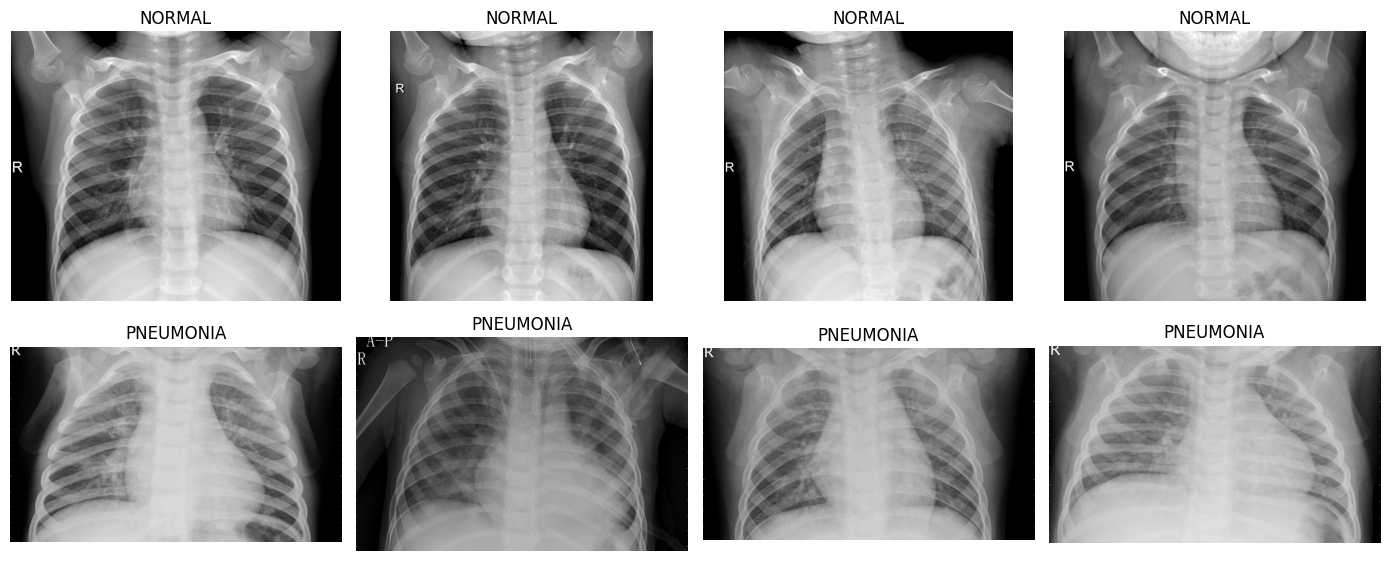

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for row, label in enumerate(['NORMAL', 'PNEUMONIA']):
    files = random.sample(os.listdir(train_dir + label), 4)
    for col, f in enumerate(files):
        img = cv2.imread(train_dir + label + '/' + f)
        axes[row][col].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axes[row][col].set_title(label); axes[row][col].axis('off')
plt.tight_layout(); plt.show()

##Model Train

In [7]:

train_gen = ImageDataGenerator(rescale=1./255, horizontal_flip=True, zoom_range=0.2).flow_from_directory(
    train_dir, target_size=(150,150), batch_size=32, class_mode='binary')
val_gen   = ImageDataGenerator(rescale=1./255).flow_from_directory(
    val_dir,   target_size=(150,150), batch_size=32, class_mode='binary')
test_gen  = ImageDataGenerator(rescale=1./255).flow_from_directory(
    test_dir,  target_size=(150,150), batch_size=32, class_mode='binary', shuffle=False)


weights = compute_class_weight('balanced', classes=np.unique(train_gen.classes), y=train_gen.classes)
class_weight_dict = dict(enumerate(weights))


model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


history = model.fit(
    train_gen, validation_data=val_gen, epochs=25,
    class_weight=class_weight_dict,
    callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)]
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 635 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 1092s 7s/step - accuracy: 0.8163 - loss: 0.4114 - val_accuracy: 0.6875 - val_loss: 0.6084
Epoch 2/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.8888 - loss: 0.2814 - val_accuracy: 0.8125 - val_loss: 0.3825
Epoch 3/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.8995 - loss: 0.2525 - val_accuracy: 0.8125 - val_loss: 0.4248
Epoch 4/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 172s 1s/step - accuracy: 0.8970 - loss: 0.2489 - val_accuracy: 0.8125 - val_loss: 0.3573
Epoch 5/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 173s 1s/step - accuracy: 0.9072 - loss: 0.2336 - val_accuracy: 0.7500 - val_loss: 0.6876
Epoch 6/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 202s 1s/step - accuracy: 0.9178 - loss: 0.2138 - val_accuracy: 0.9375 - val_loss: 0.3234
Epoch 7/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 169s 1s/step - accuracy: 0.9189 - loss: 0.2043 - val_accuracy: 0.8125 - val_loss: 0.4278
Epoch 8/25
163/163 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.9216 - loss: 0.1933 - val_acc

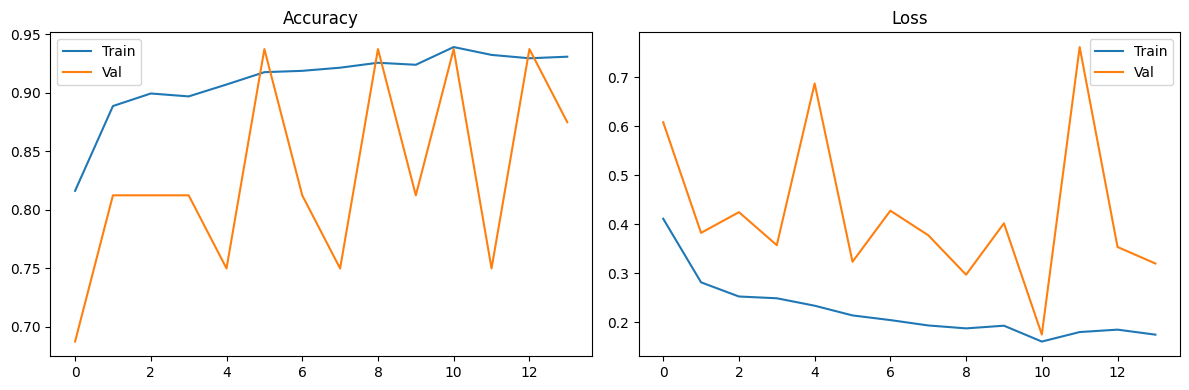

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric in zip(axes, ['accuracy', 'loss']):
    ax.plot(history.history[metric],     label='Train')
    ax.plot(history.history['val_'+metric], label='Val')
    ax.set_title(metric.capitalize()); ax.legend()
plt.tight_layout(); plt.show()

##Evaluation

Test Accuracy: 0.8913  |  Test Loss: 0.3142
              precision    recall  f1-score   support

      Normal       0.86      0.86      0.86       245
   Pneumonia       0.91      0.91      0.91       390

    accuracy                           0.89       635
   macro avg       0.89      0.88      0.89       635
weighted avg       0.89      0.89      0.89       635



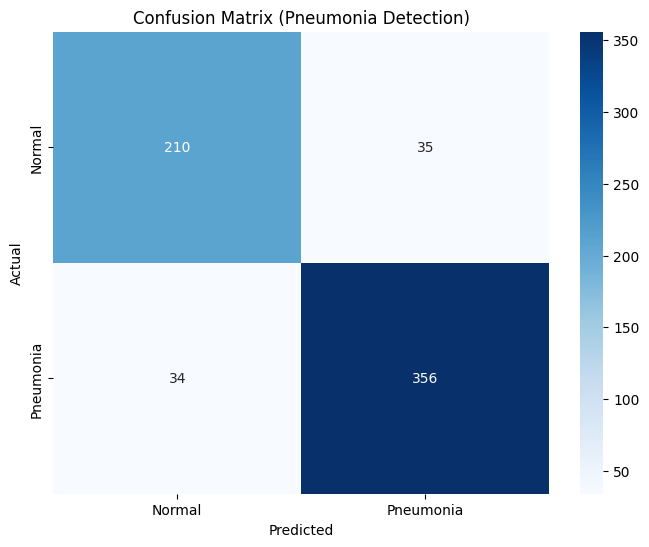

In [12]:
loss, acc = model.evaluate(test_gen, verbose=0)
print(f"Test Accuracy: {acc:.4f}  |  Test Loss: {loss:.4f}")


test_gen.reset()
y_pred = (model.predict(test_gen, verbose=0) > 0.5).astype(int).flatten()
y_true = test_gen.classes

print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Pneumonia'],
            yticklabels=['Normal', 'Pneumonia'])

plt.title('Confusion Matrix (Pneumonia Detection)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()